# Combine Two YOLO Models on the Same NFL Frame (No Homography Yet)

This notebook:

- Loads **two trained YOLO models**:
  - A *field model* (detects hashes, numbers, etc.)
  - A *player model* (detects players)
- Runs **both models on the same input image**
- Extracts detections from each
- Combines the outputs into a single Python structure

> This version does **not** do any homography / field-coordinate mapping.  
> It only combines raw pixel-space detections.


In [90]:
import os
import sys
from pathlib import Path

import cv2
import numpy as np
from ultralytics import YOLO

print("Python:", sys.version)
print("CWD:", os.getcwd())

# ========================
# CONFIG: UPDATE THESE PATHS
# ========================

# Path to trained YOLO models
# Make sure these point to your actual best.pt files (usually under runs/train/.../weights/best.pt)
FIELD_MODEL_WEIGHTS = "runs/detect/football_yolo11n2/weights/best.pt"     # field / hash / number model
PLAYER_MODEL_WEIGHTS = "runs/detect/football_positions3/weights/best.pt" # player detector
NUMBER_MODEL_WEIGHTS = "runs/classify/train4/weights/best.pt"

# Path to an example NFL frame
IMAGE_PATH = "data/Football Player Detection.v7i.yolov11/train/images/57508_003904_Sideline_frame173_jpg.rf.f3e31645a2a8c78771919efe4c353876.jpg"  # e.g. "test/images/frame_0001.jpg"
# IMAGE_PATH = "data/Football Player Detection.v7i.yolov11/train/images/57509_000776_Sideline_frame55_jpg.rf.ffd088d5cefb34756b9cd4ab7ec9a63a.jpg" 


print("Field model weights:", FIELD_MODEL_WEIGHTS)
print("Player model weights:", PLAYER_MODEL_WEIGHTS)
print("Example image path:", IMAGE_PATH)

Python: 3.9.6 (default, Oct 17 2025, 17:15:53) 
[Clang 17.0.0 (clang-1700.4.4.1)]
CWD: /Users/lucaspedemonte/Documents/VSCode/NFL_Play_Classifier/NFL_Play_Outcome_Classifier
Field model weights: runs/detect/football_yolo11n2/weights/best.pt
Player model weights: runs/detect/football_positions3/weights/best.pt
Example image path: data/Football Player Detection.v7i.yolov11/train/images/57508_003904_Sideline_frame173_jpg.rf.f3e31645a2a8c78771919efe4c353876.jpg


In [91]:
# ========================
# Load YOLO Models
# ========================

if not os.path.exists(FIELD_MODEL_WEIGHTS):
    print(f"⚠️ Field model weights not found at: {FIELD_MODEL_WEIGHTS}")
else:
    print(f"✅ Found field model at: {FIELD_MODEL_WEIGHTS}")

if not os.path.exists(PLAYER_MODEL_WEIGHTS):
    print(f"⚠️ Player model weights not found at: {PLAYER_MODEL_WEIGHTS}")
else:
    print(f"✅ Found player model at: {PLAYER_MODEL_WEIGHTS}")

if not os.path.exists(NUMBER_MODEL_WEIGHTS):
    print(f"⚠️ Player model weights not found at: {NUMBER_MODEL_WEIGHTS}")
else:
    print(f"✅ Found player model at: {NUMBER_MODEL_WEIGHTS}")

field_model = YOLO(FIELD_MODEL_WEIGHTS)
player_model = YOLO(PLAYER_MODEL_WEIGHTS)
number_model = YOLO(NUMBER_MODEL_WEIGHTS)

print("Field model classes:", field_model.names)
print("Player model classes:", player_model.names)
print("Number model classes:", number_model.names)

✅ Found field model at: runs/detect/football_yolo11n2/weights/best.pt
✅ Found player model at: runs/detect/football_positions3/weights/best.pt
✅ Found player model at: runs/classify/train4/weights/best.pt
Field model classes: {0: 'ball', 1: 'five_hash', 2: 'hash', 3: 'marker', 4: 'number', 5: 'player', 6: 'pylon', 7: 'ref'}
Player model classes: {0: 'C', 1: 'DB', 2: 'LB', 3: 'QB', 4: 'SKILL'}
Number model classes: {0: '10', 1: '20', 2: '30', 3: '40', 4: '50'}


In [92]:
# ========================
# Helper: Convert YOLO Results to Dicts
# ========================

def extract_detections(result):
    """Convert a YOLO result object into a list of simple dicts.
    
    Each dict:
    {
        'class_id': int,
        'class_name': str,
        'confidence': float,
        'bbox': (x1, y1, x2, y2)
    }
    """
    det_list = []
    names = result.names
    
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        
        det_list.append({
            "class_id": cls_id,
            "class_name": names[cls_id],
            "confidence": conf,
            "bbox": (x1, y1, x2, y2),
        })
    return det_list

In [93]:
# ========================
# Run All Models on the Same Image
# ========================

# Load the image
img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Could not load image at: {IMAGE_PATH}")

# ------------------------
# 1. Run the field model
# ------------------------
print("Running field model...")
field_results = field_model(img)[0]   # first (and only) image in batch
field_dets = extract_detections(field_results)
print(f"Field detections: {len(field_dets)}")

# Add yard-number classification for 'number' detections
for det in field_dets:
    if "number" not in det["class_name"].lower():
        continue

    x1, y1, x2, y2 = map(int, det["bbox"])
    crop_bgr = img[y1:y2, x1:x2]
    if crop_bgr.size == 0:
        continue

    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

    # classify with number model
    r = number_model(crop_rgb)[0]
    cls_id = int(r.probs.top1)
    yard_label = number_model.names[cls_id]
    conf = float(r.probs.top1conf)

    # attach prediction to this detection
    det["yard_number_pred"] = yard_label
    det["yard_number_conf"] = conf

# ------------------------
# 2. Run the player model
# ------------------------
print("\nRunning player model...")
player_results = player_model(img)[0]
player_dets = extract_detections(player_results)
print(f"Player detections: {len(player_dets)}")

# ------------------------
# 3. Combine outputs
# ------------------------
combined_output = {
    "field": field_dets,    # now includes yard_number_pred/conf on number boxes
    "players": player_dets,
}

combined_output

Running field model...

0: 736x1280 8 five_hashs, 39 hashs, 5 numbers, 97.5ms
Speed: 4.9ms preprocess, 97.5ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)
Field detections: 52

0: 64x64 50 0.88, 40 0.11, 30 0.01, 10 0.00, 20 0.00, 1.6ms
Speed: 0.5ms preprocess, 1.6ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 30 0.60, 20 0.19, 40 0.08, 10 0.08, 50 0.05, 1.3ms
Speed: 0.5ms preprocess, 1.3ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 40 0.80, 50 0.19, 30 0.01, 10 0.00, 20 0.00, 1.5ms
Speed: 0.6ms preprocess, 1.5ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 50 0.90, 30 0.08, 40 0.01, 20 0.01, 10 0.00, 1.3ms
Speed: 0.5ms preprocess, 1.3ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 30 0.87, 20 0.08, 10 0.04, 50 0.01, 40 0.00, 1.4ms
Speed: 0.4ms preprocess, 1.4ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

Running player model...

0:

{'field': [{'class_id': 4,
   'class_name': 'number',
   'confidence': 0.8955503106117249,
   'bbox': (222.73834228515625,
    134.1251220703125,
    364.49530029296875,
    174.93063354492188),
   'yard_number_pred': '50',
   'yard_number_conf': 0.8787746429443359},
  {'class_id': 1,
   'class_name': 'five_hash',
   'confidence': 0.8913627862930298,
   'bbox': (1085.2928466796875,
    273.5357971191406,
    1116.6549072265625,
    279.8643493652344)},
  {'class_id': 4,
   'class_name': 'number',
   'confidence': 0.8865867257118225,
   'bbox': (975.2738037109375,
    117.63916015625,
    1118.6973876953125,
    159.41299438476562),
   'yard_number_pred': '30',
   'yard_number_conf': 0.6034489274024963},
  {'class_id': 1,
   'class_name': 'five_hash',
   'confidence': 0.8776766657829285,
   'bbox': (472.93499755859375,
    287.60772705078125,
    503.19775390625,
    294.18328857421875)},
  {'class_id': 2,
   'class_name': 'hash',
   'confidence': 0.8339480757713318,
   'bbox': (1264.29

Combined detections summary:
{'field': [{'bbox': (222.73834228515625,
                     134.1251220703125,
                     364.49530029296875,
                     174.93063354492188),
            'class_id': 4,
            'class_name': 'number',
            'confidence': 0.8955503106117249,
            'yard_number_conf': 0.8787746429443359,
            'yard_number_pred': '50'},
           {'bbox': (1085.2928466796875,
                     273.5357971191406,
                     1116.6549072265625,
                     279.8643493652344),
            'class_id': 1,
            'class_name': 'five_hash',
            'confidence': 0.8913627862930298},
           {'bbox': (975.2738037109375,
                     117.63916015625,
                     1118.6973876953125,
                     159.41299438476562),
            'class_id': 4,
            'class_name': 'number',
            'confidence': 0.8865867257118225,
            'yard_number_conf': 0.6034489274024963,
         

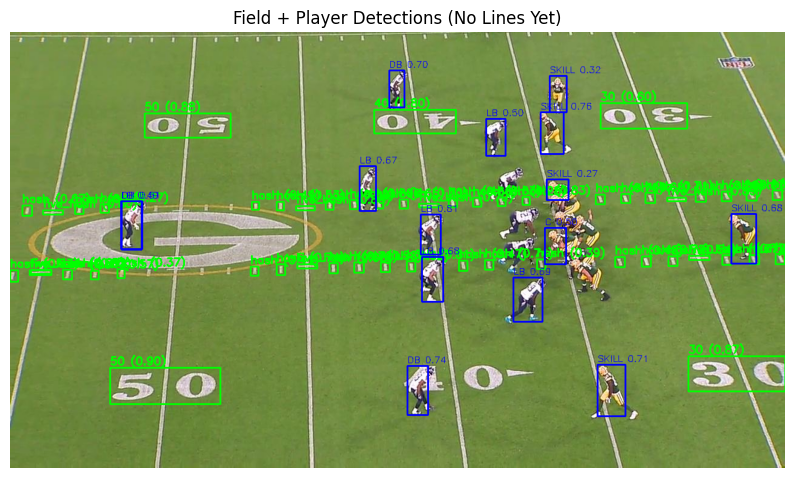

In [94]:
# ========================
# Pretty Print & Visualize Detections (NO NUMBER–HASH LINES)
# ========================
from pprint import pprint
import matplotlib.pyplot as plt
import cv2

print("Combined detections summary:")
pprint(combined_output)

vis = img.copy()

# ---- 1. Draw field detections ----
for det in combined_output["field"]:
    x1, y1, x2, y2 = map(int, det["bbox"])

    if "number" in det["class_name"].lower() and "yard_number_pred" in det:
        label = f"{det['yard_number_pred']} ({det['yard_number_conf']:.2f})"
    else:
        label = f"{det['class_name']} ({det['confidence']:.2f})"

    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        vis,
        label,
        (x1, max(0, y1 - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# ---- 2. Draw player detections ----
for det in combined_output["players"]:
    x1, y1, x2, y2 = map(int, det["bbox"])
    label = f"{det['class_name']} {det['confidence']:.2f}"
    cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(
        vis,
        label,
        (x1, max(y1 - 5, 0)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Field + Player Detections (No Lines Yet)")
plt.show()

✅ Using yardline 50 as baseline
Found 3 hash lanes.
Found 2 hash rows.


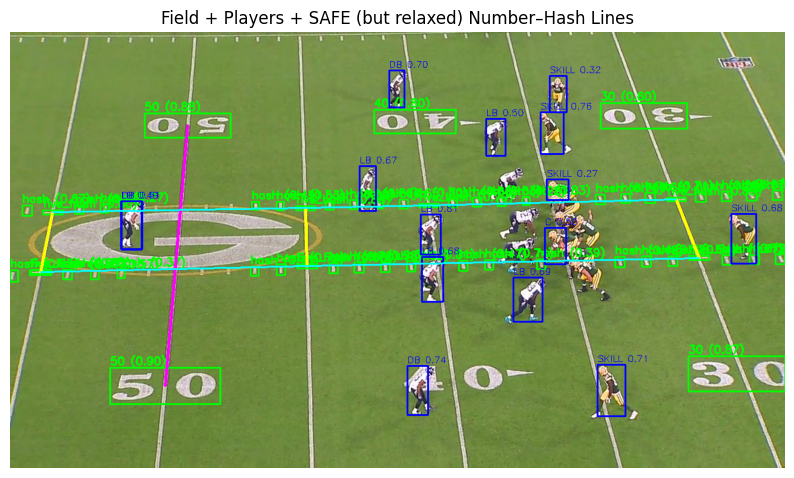

In [95]:
# ========================
# Draw Number–Hash Lines (with relaxed rules)
# ========================
import math
from collections import defaultdict

vis2 = vis.copy()
field_dets = combined_output["field"]

# Extract number & five-hash detections
number_dets = [
    d for d in field_dets
    if "number" in d["class_name"].lower() and "yard_number_pred" in d
]

five_hash_dets = [
    d for d in field_dets
    if "five_hash" in d["class_name"].lower()
]

def bbox_center(det):
    x1, y1, x2, y2 = det["bbox"]
    return 0.5 * (x1 + x2), 0.5 * (y1 + y2)

for d in number_dets:
    d["center"] = bbox_center(d)

for d in five_hash_dets:
    d["center"] = bbox_center(d)

# Group by predicted yard number, require decent confidence
numbers_by_label = defaultdict(list)
for d in number_dets:
    if d["yard_number_conf"] >= 0.6:   # was 0.7
        numbers_by_label[d["yard_number_pred"]].append(d)

# Relaxed geometry thresholds
MAX_X_DIFF_SAME_YARD = 80   # was 40
MIN_Y_DIFF_SAME_YARD = 60   # was 80
MAX_HASH_X_OFFSET = 80      # was 40
MAX_HASH_Y_MARGIN  = 60     # was 40

used_hashes = set()

# ========================
# Choose BEST opposite-side number pair and draw ONLY that line
# ========================

best_pair = None
best_score = -1.0

for label, dets in numbers_by_label.items():
    if len(dets) < 2:
        continue

    # sort by confidence (highest first)
    dets_sorted = sorted(dets, key=lambda d: d["yard_number_conf"], reverse=True)

    # try the two best detections for this label
    d1, d2 = dets_sorted[0], dets_sorted[1]
    cx1, cy1 = d1["center"]
    cx2, cy2 = d2["center"]

    dx = abs(cx1 - cx2)
    dy = abs(cy1 - cy2)

    # geometry sanity
    if dx > MAX_X_DIFF_SAME_YARD or dy < MIN_Y_DIFF_SAME_YARD:
        continue

    # score = combined confidence
    score = d1["yard_number_conf"] + d2["yard_number_conf"]

    if score > best_score:
        # assign near (bottom) vs far (top)
        if cy1 > cy2:
            near_det, far_det = d1, d2
        else:
            near_det, far_det = d2, d1

        best_pair = (label, near_det, far_det)
        best_score = score

# If no valid pair, abort gracefully
if best_pair is None:
    print("⚠️ No valid opposite number pair found.")
else:
    label, near_det, far_det = best_pair
    print(f"✅ Using yardline {label} as baseline")

    cx1, cy1 = near_det["center"]
    cx2, cy2 = far_det["center"]

    p1 = (int(cx1), int(cy1))
    p2 = (int(cx2), int(cy2))

    # Draw ONLY this line
    cv2.line(vis2, p1, p2, (255, 0, 255), 3)

    # Now try to add one hash in-between (same logic as before)
    avg_x = 0.5 * (cx1 + cx2)
    y_min, y_max = sorted([cy1, cy2])

    candidates = []
    for idx, h in enumerate(five_hash_dets):
        cxh, cyh = h["center"]

        if abs(cxh - avg_x) > MAX_HASH_X_OFFSET:
            continue
        if not (y_min - MAX_HASH_Y_MARGIN <= cyh <= y_max + MAX_HASH_Y_MARGIN):
            continue

        dist = math.hypot(cxh - avg_x, cyh - (0.5 * (y_min + y_max)))
        candidates.append((dist, idx, h))

    if candidates:
        _, h_idx, h = sorted(candidates, key=lambda t: t[0])[0]
        cxh, cyh = h["center"]
        ph = (int(cxh), int(cyh))

        cv2.line(vis2, p1, ph, (255, 0, 0), 2)
        cv2.line(vis2, ph, p2, (255, 0, 0), 2)

# ================================
# Draw hash "grid": vertical lanes + horizontal connections
# ================================

# ================================
# Draw hash "grid": vertical lanes + horizontal connections
# ================================

# Tuneable thresholds
HASH_CONF_THRESH = 0.4        # minimum confidence for hash to use
HASH_LANE_X_THRESH = 60       # max x distance to stay in same lane
HASH_LANE_MIN_Y_SPAN = 80     # min vertical span to draw a vertical lane
HASH_PAIR_Y_MATCH = 30        # max y difference to consider two hashes same row

# Filter hashes by confidence (optional but usually helpful)
usable_hashes = [h for h in five_hash_dets if h.get("confidence", 1.0) >= HASH_CONF_THRESH]
if len(usable_hashes) < 2:
    print("Not enough confident hash detections to draw hash grid.")
else:
    # ---- GLOBAL hash span in X: we'll draw horizontals across this full range ----
    hash_xs = [h["center"][0] for h in usable_hashes]
    global_min_x = min(hash_xs)
    global_max_x = max(hash_xs)

    # ---- 1. Cluster hashes into vertical lanes (left hash / right hash) by x ----
    usable_hashes_sorted = sorted(usable_hashes, key=lambda d: d["center"][0])

    lanes = []
    current_lane = [usable_hashes_sorted[0]]

    for h1, h2 in zip(usable_hashes_sorted, usable_hashes_sorted[1:]):
        x1 = h1["center"][0]
        x2 = h2["center"][0]
        if abs(x1 - x2) < HASH_LANE_X_THRESH:
            current_lane.append(h2)
        else:
            lanes.append(current_lane)
            current_lane = [h2]
    lanes.append(current_lane)

    # Only keep lanes with at least 2 points
    lanes = [lane for lane in lanes if len(lane) >= 2]

    print(f"Found {len(lanes)} hash lanes.")

    # ---- 2. Draw vertical lines down each hash lane ----
    for lane in lanes:
        # sort by y (top to bottom)
        lane_sorted = sorted(lane, key=lambda d: d["center"][1])
        top_h = lane_sorted[0]
        bot_h = lane_sorted[-1]

        cx1, cy1 = top_h["center"]
        cx2, cy2 = bot_h["center"]

        y_span = abs(cy2 - cy1)
        x_span = abs(cx2 - cx1)

        if y_span < HASH_LANE_MIN_Y_SPAN:
            continue  # too short, probably noise

        # We expect hash lanes to be mostly vertical
        if x_span > HASH_LANE_X_THRESH * 2:
            continue

        p_top = (int(cx1), int(cy1))
        p_bot = (int(cx2), int(cy2))

        # yellow vertical lane line
        cv2.line(vis2, p_top, p_bot, (0, 255, 255), 3)

        # ---- 3. Draw slanted polylines through ALL hashes in each row ----

    # 3a. Cluster all usable hashes into horizontal "rows" based on y
    all_hashes_sorted_by_y = sorted(usable_hashes, key=lambda d: d["center"][1])

    rows = []
    for h in all_hashes_sorted_by_y:
        y = h["center"][1]
        placed = False

        for row in rows:
            # Use the average y of the row as its representative height
            row_y = sum(r["center"][1] for r in row) / len(row)
            if abs(y - row_y) <= HASH_PAIR_Y_MATCH:
                row.append(h)
                placed = True
                break

        if not placed:
            rows.append([h])

    # Keep only rows that have at least 2 hashes
    rows = [row for row in rows if len(row) >= 2]

    print(f"Found {len(rows)} hash rows.")

    # 3b. For each row, connect all hashes from left to right
    for row in rows:
        row_sorted = sorted(row, key=lambda d: d["center"][0])

        for h1, h2 in zip(row_sorted, row_sorted[1:]):
            x1, y1 = h1["center"]
            x2, y2 = h2["center"]

            p1 = (int(x1), int(y1))
            p2 = (int(x2), int(y2))

            # cyan line segment through adjacent hashes
            cv2.line(vis2, p1, p2, (255, 255, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Field + Players + SAFE (but relaxed) Number–Hash Lines")
plt.show()

✓ Baseline: 50 yard line
✓ Across-field: 14.73 pixels/yard
✓ Along-field: 439.89 pixels/yard
✓ Baseline center: (275.0, 369.5)

✓ Transformed 15 players

Sample positions:
  LB              → X= 50.95 yd, Y=29.26 yd
  SKILL           → X= 51.37 yd, Y=41.63 yd
  DB              → X= 50.95 yd, Y=11.20 yd
  SKILL           → X= 51.68 yd, Y=12.95 yd
  DB              → X= 50.78 yd, Y=45.38 yd
  LB              → X= 51.34 yd, Y=22.71 yd
  SKILL           → X= 52.12 yd, Y=31.27 yd
  LB              → X= 50.97 yd, Y=23.96 yd


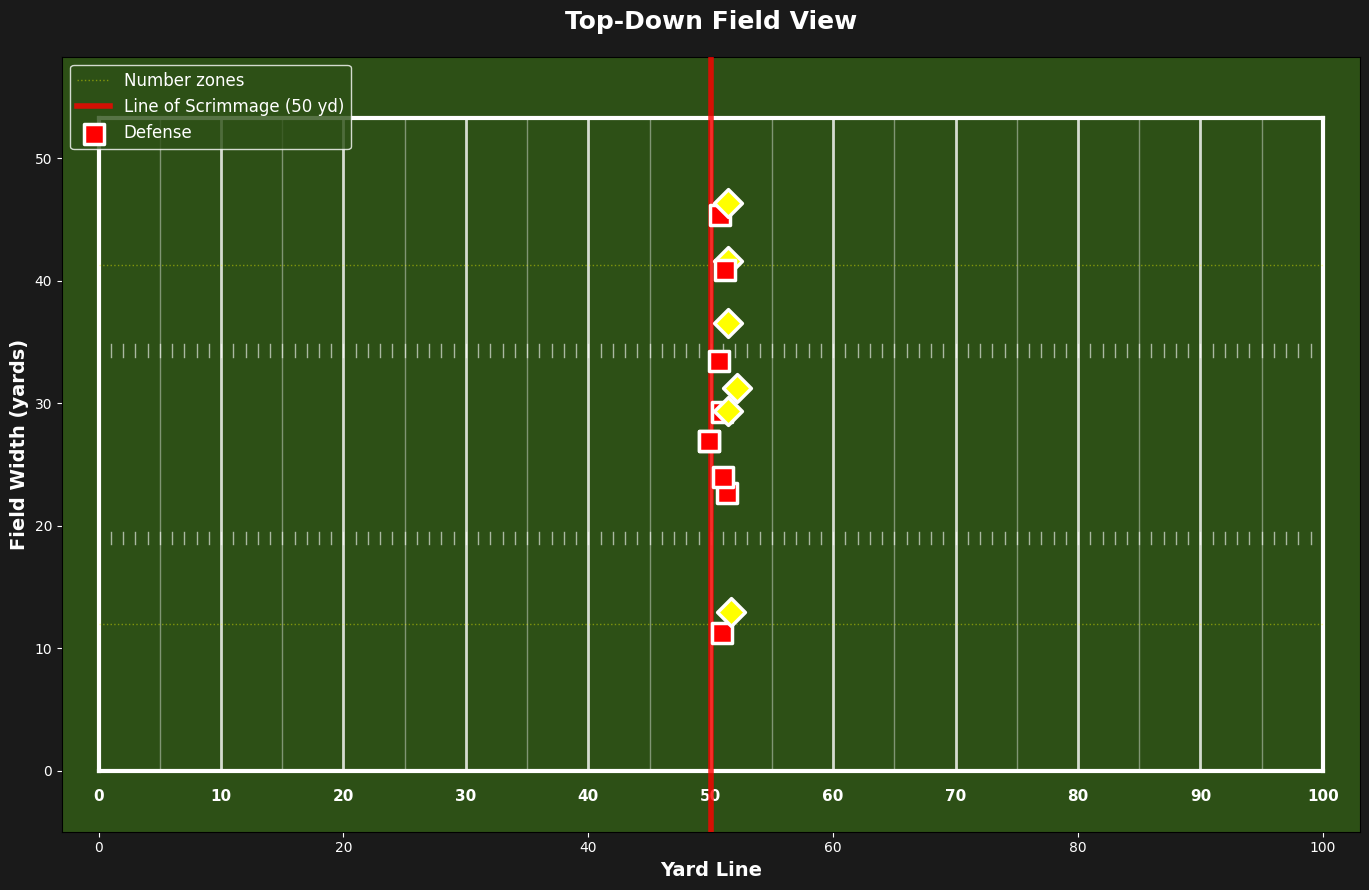


✓ TRANSFORMATION COMPLETE


In [96]:
import numpy as np

# ============================================================================
# SIMPLIFIED COORDINATE TRANSFORMATION
# Uses baseline yard numbers and hash rows to map pixel -> field coordinates
# ============================================================================

# -----------------------------
# 1. Baseline Setup (Yard Numbers)
# -----------------------------
# Inputs from your selection:
# - baseline_label: int (e.g., 40, 50, etc.)
# - near_det: dict with "center" key [x, y] (near sideline number)
# - far_det: dict with "center" key [x, y] (far sideline number)

p_near = np.array(near_det["center"], dtype=np.float32)
p_far = np.array(far_det["center"], dtype=np.float32)

# Vector across field (from near to far sideline)
v_across = p_far - p_near
across_len = np.linalg.norm(v_across)
v_across_unit = v_across / (across_len + 1e-6)

# Physical calibration: numbers are 12 yards from each sideline
FIELD_WIDTH = 53.3
NUM_OFFSET = 12.0
physical_span = FIELD_WIDTH - 2.0 * NUM_OFFSET  # 29.3 yards
pixels_per_yard_across = across_len / physical_span

# Perpendicular direction (along field, perpendicular to baseline)
# Rotate v_across by 90 degrees
v_along_unit = np.array([-v_across_unit[1], v_across_unit[0]])

print(f"✓ Baseline: {baseline_label} yard line")
print(f"✓ Across-field: {pixels_per_yard_across:.2f} pixels/yard")


# -----------------------------
# 2. Hash Row Setup (Along-Field Axis)
# -----------------------------
def choose_reference_hash_row(rows, near_det, far_det):
    """Choose hash row closest to baseline (midpoint between numbers)."""
    target_y = 0.5 * (near_det["center"][1] + far_det["center"][1])
    
    best_row = None
    best_dy = float('inf')
    for row in rows:
        ys = [h["center"][1] for h in row]
        row_y = sum(ys) / len(ys)
        dy = abs(row_y - target_y)
        if dy < best_dy:
            best_row, best_dy = row, dy
    return best_row

if not rows:
    raise RuntimeError("No hash rows found")

ref_row = choose_reference_hash_row(rows, near_det, far_det)
ref_row_sorted = sorted(ref_row, key=lambda d: d["center"][0])

# Calculate along-field calibration from hash spacing (1 yard apart)
hash_x_positions = []
for h in ref_row_sorted:
    hash_x_positions.append(h["center"][0])

hash_x_positions = sorted(hash_x_positions)
if len(hash_x_positions) >= 2:
    hash_spacings = np.diff(hash_x_positions)
    pixels_per_yard_along = np.median(hash_spacings)  # 1 yard between hashes
else:
    pixels_per_yard_along = pixels_per_yard_across  # fallback

print(f"✓ Along-field: {pixels_per_yard_along:.2f} pixels/yard")


# -----------------------------
# 3. Coordinate System Origin
# -----------------------------
# Use the midpoint between near and far numbers as baseline origin
baseline_center = 0.5 * (p_near + p_far)

print(f"✓ Baseline center: ({baseline_center[0]:.1f}, {baseline_center[1]:.1f})")


# -----------------------------
# 4. Transform Pixel (u,v) → Field (X,Y)
# -----------------------------
def image_to_field_xy(point_uv):
    """
    Map pixel (u,v) to field (X,Y) in yards.
    
    X: yards along field (0-100)
       - baseline_label at the baseline
       - positive = downfield direction (perpendicular to baseline, toward opponent)
       
    Y: yards across field (0-53.3)
       - 0 = near sideline
       - 53.3 = far sideline
    """
    p = np.array(point_uv, dtype=np.float32)
    
    # Vector from baseline center to point
    delta = p - baseline_center
    
    # === FIELD X (along-field, perpendicular to baseline) ===
    # Project onto along-field direction
    pixels_along = np.dot(delta, v_along_unit)
    yards_along = pixels_along / pixels_per_yard_along
    X = baseline_label + yards_along
    
    # === FIELD Y (across-field, parallel to baseline) ===
    # Project onto across-field direction
    pixels_across = np.dot(delta, v_across_unit)
    yards_across = pixels_across / pixels_per_yard_across
    Y = NUM_OFFSET + physical_span / 2.0 + yards_across  # Center at field middle
    
    # Clamp to field boundaries
    X = np.clip(X, 0, 100)
    Y = np.clip(Y, 0, FIELD_WIDTH)
    
    return float(X), float(Y)


# -----------------------------
# 5. Transform All Players
# -----------------------------
player_field_positions = []

for d in combined_output["players"]:
    x1, y1, x2, y2 = d["bbox"]
    
    # Use bottom-center of bounding box (feet)
    cx = 0.5 * (x1 + x2)
    cy = y2  # Bottom edge
    
    X, Y = image_to_field_xy((cx, cy))
    
    d["image_center"] = (cx, cy)
    d["field_xy"] = (X, Y)
    
    player_field_positions.append({
        "class_name": d["class_name"],
        "image_center": (cx, cy),
        "field_x": X,
        "field_y": Y,
        "confidence": d.get("confidence", 0.0)
    })

print(f"\n✓ Transformed {len(player_field_positions)} players")
print("\nSample positions:")
for p in player_field_positions[:8]:
    print(f"  {p['class_name']:15s} → X={p['field_x']:6.2f} yd, Y={p['field_y']:5.2f} yd")


# -----------------------------
# 6. Visualization
# -----------------------------
def plot_field_top_down(player_positions, baseline_yard):
    """Plot players on regulation NFL field (top-down view)."""
    fig, ax = plt.subplots(figsize=(16, 9))
    
    # Field boundaries
    ax.plot([0, 100], [0, 0], 'white', linewidth=3)
    ax.plot([0, 100], [FIELD_WIDTH, FIELD_WIDTH], 'white', linewidth=3)
    ax.plot([0, 0], [0, FIELD_WIDTH], 'white', linewidth=3)
    ax.plot([100, 100], [0, FIELD_WIDTH], 'white', linewidth=3)
    
    # Yard lines (every 5 yards)
    for yard in range(0, 101, 5):
        alpha = 0.8 if yard % 10 == 0 else 0.4
        width = 2 if yard % 10 == 0 else 1
        ax.plot([yard, yard], [0, FIELD_WIDTH], 'white', 
                alpha=alpha, linewidth=width)
        if yard % 10 == 0:
            ax.text(yard, -2.5, str(yard), ha='center', 
                   color='white', fontsize=11, fontweight='bold')
    
    # Hash marks
    for yard in range(0, 101):
        ax.plot([yard, yard], [18.5, 19.5], 'white', linewidth=1, alpha=0.6)
        ax.plot([yard, yard], [33.8, 34.8], 'white', linewidth=1, alpha=0.6)
    
    # Numbers location reference
    ax.plot([0, 100], [NUM_OFFSET, NUM_OFFSET], 'yellow', 
            linewidth=1, linestyle=':', alpha=0.4, label='Number zones')
    ax.plot([0, 100], [FIELD_WIDTH - NUM_OFFSET, FIELD_WIDTH - NUM_OFFSET], 
            'yellow', linewidth=1, linestyle=':', alpha=0.4)
    
    # Line of scrimmage (baseline)
    ax.axvline(baseline_yard, color='red', linewidth=4, 
              label=f'Line of Scrimmage ({baseline_yard} yd)', zorder=5, alpha=0.8)
    
    # Plot players
    offense_keywords = ['offense', 'qb', 'rb', 'wr', 'te', 'ol', 'off']
    defense_keywords = ['defense', 'dl', 'lb', 'db', 'safety', 'def']
    
    offense_plotted = False
    defense_plotted = False
    
    for p in player_positions:
        x = p['field_x']
        y = p['field_y']
        class_lower = p['class_name'].lower()
        
        # Classify player
        if any(kw in class_lower for kw in offense_keywords):
            color = 'cyan'
            marker = 'o'
            label = 'Offense' if not offense_plotted else None
            offense_plotted = True
        elif any(kw in class_lower for kw in defense_keywords):
            color = 'red'
            marker = 's'
            label = 'Defense' if not defense_plotted else None
            defense_plotted = True
        else:
            color = 'yellow'
            marker = 'D'
            label = None
        
        ax.scatter(x, y, c=color, s=200, marker=marker, 
                  edgecolors='white', linewidth=2.5, zorder=10, label=label)
    
    # Styling
    ax.set_facecolor('#2d5016')  # Field green
    ax.set_xlim(-3, 103)
    ax.set_ylim(-5, FIELD_WIDTH + 5)
    ax.set_xlabel('Yard Line', fontsize=14, fontweight='bold', color='white')
    ax.set_ylabel('Field Width (yards)', fontsize=14, fontweight='bold', color='white')
    ax.set_title('Top-Down Field View', fontsize=18, fontweight='bold', color='white', pad=20)
    ax.tick_params(colors='white')
    ax.legend(loc='upper left', fontsize=12, facecolor='#2d5016', 
             edgecolor='white', labelcolor='white')
    ax.set_aspect('equal')
    fig.patch.set_facecolor('#1a1a1a')
    
    plt.tight_layout()
    return fig

# Create visualization
fig = plot_field_top_down(player_field_positions, baseline_label)
plt.show()

print("\n" + "="*60)
print("✓ TRANSFORMATION COMPLETE")
print("="*60)

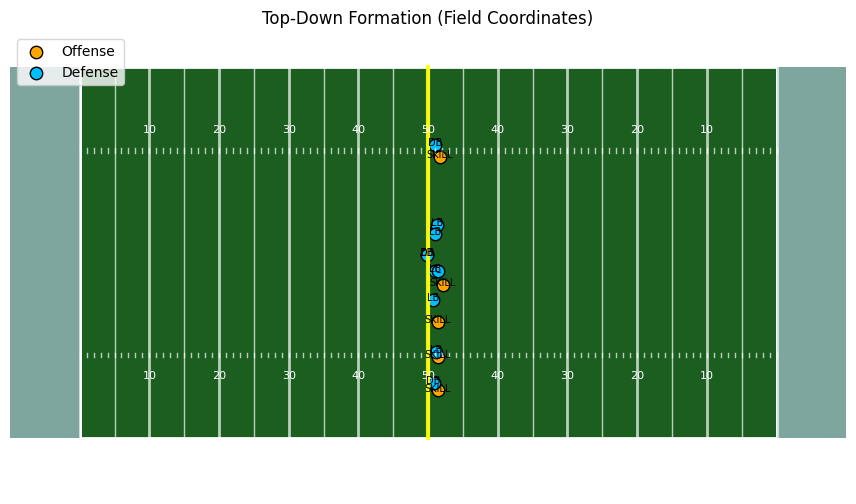

In [97]:
def plot_players_on_field(player_field_positions, los_x=50.0, offense_dir="right"):
    """
    Plot players in field coordinates on the drawn field.

    Parameters
    ----------
    player_field_positions : list[dict]
        Each dict must contain:
            - 'field_x': x position in yards (0–100)
            - 'field_y': y position in yards (0–53.3)
            - 'class_name': label string (e.g. 'QB', 'WR', 'DB', ...)
    los_x : float or None
        Optional line-of-scrimmage x coordinate in yards.
    offense_dir : {"right", "left"}
        Direction the offense is going for the arrow annotation.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    draw_field(ax)

    # Optional: line of scrimmage (e.g. 50 if that's the yard line you calibrated on)
    if los_x is not None:
        ax.plot(
            [los_x, los_x],
            [0, FIELD_WIDTH],
            color="yellow",
            linewidth=3,
            alpha=0.9,
        )

    # Example split: offense vs defense by class_name substring
    off_x, off_y = [], []
    def_x, def_y = [], []
    for p in player_field_positions:
        X, Y = p["field_x"], p["field_y"]
        name = p["class_name"].lower()

        # Tweak these tokens to match your labels
        if any(t in name for t in ["qb", "rb", "wr", "te", "ol", "skill"]):
            off_x.append(X)
            off_y.append(Y)
        else:
            def_x.append(X)
            def_y.append(Y)

    # Plot offense & defense as different colored circles
    ax.scatter(
        off_x,
        off_y,
        s=80,
        edgecolors="black",
        facecolors="orange",
        label="Offense",
    )
    ax.scatter(
        def_x,
        def_y,
        s=80,
        edgecolors="black",
        facecolors="deepskyblue",
        label="Defense",
    )

    # Label each player with their role text
    for p in player_field_positions:
        X, Y = p["field_x"], p["field_y"]
        ax.text(
            X,
            Y - 1.0,
            p["class_name"],
            ha="center",
            va="top",
            fontsize=7,
            color="black",
        )

    # Direction-of-play arrow above the field
    arrow_y = FIELD_WIDTH + 2
    base_start = 0.4 * FIELD_LENGTH
    base_end   = 0.7 * FIELD_LENGTH
    if offense_dir == "right":
        arrow_start, arrow_end = base_start, base_end
    else:
        arrow_start, arrow_end = base_end, base_start

    ax.annotate(
        "",
        xy=(arrow_end, arrow_y),
        xytext=(arrow_start, arrow_y),
        arrowprops=dict(arrowstyle="->", color="white", linewidth=2),
    )
    ax.text(
        (arrow_start + arrow_end) / 2,
        arrow_y + 1,
        "Offense Direction",
        color="white",
        ha="center",
        va="bottom",
        fontsize=9,
    )

    # Axes limits and style
    ax.set_xlim(-10, FIELD_LENGTH + 10)      # show endzone strips too
    ax.set_ylim(-5, FIELD_WIDTH + 8)         # extra headroom for arrow
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()                        # bottom sideline at bottom of plot
    ax.axis("off")
    ax.legend(loc="upper left")
    plt.title("Top-Down Formation (Field Coordinates)")
    plt.show()

# ---- Call this after Block A has built `player_field_positions` ----
plot_players_on_field(player_field_positions, los_x=50.0, offense_dir="right")

## Next Steps

From here you can:

- Loop over many frames and collect `combined_output` into a list or a CSV.
- Add homography later to convert pixel `(x, y)` centers into field coordinates in yards.
- Use the combined detections as input features to your **play outcome classifier**.

To adapt this to a folder of images, you can replace `IMAGE_PATH` with a loop over a directory:
```python
from glob import glob

for path in glob("frames/*.jpg"):
    # run the same pipeline on each image
    ...
```